Dataset Generation

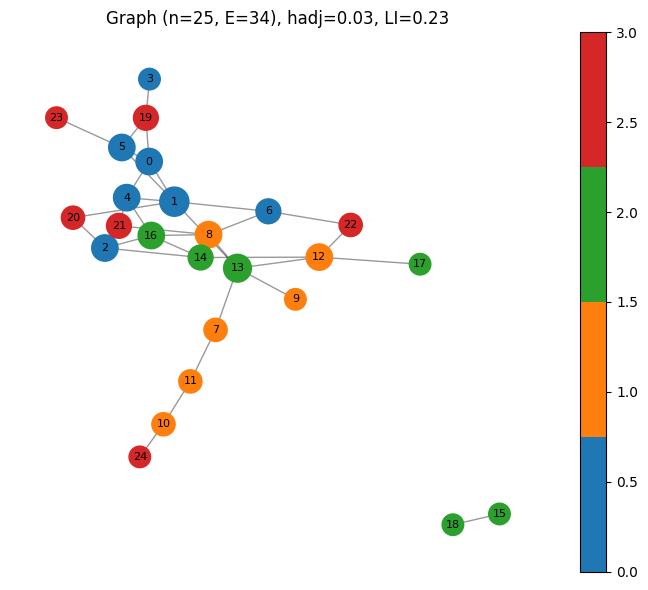

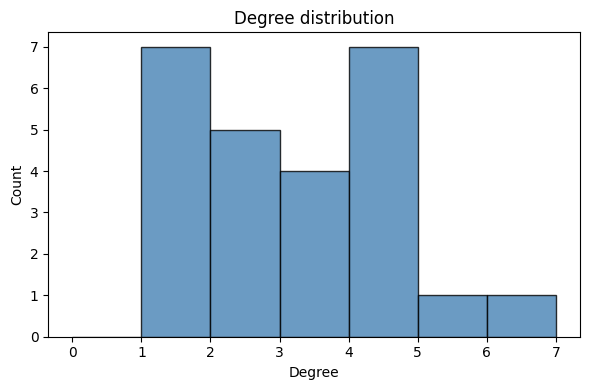

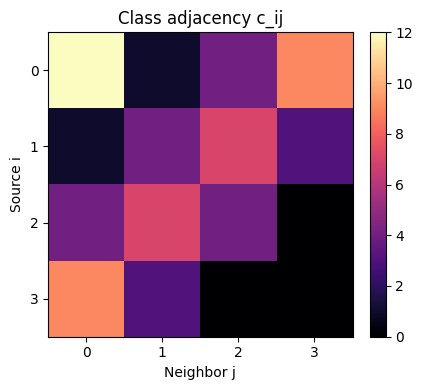

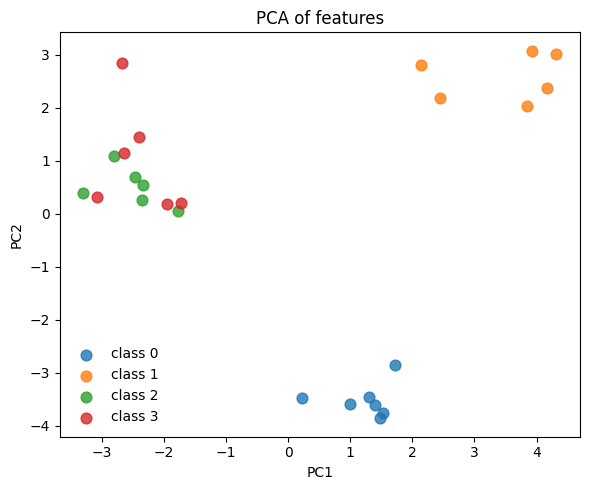

[A] done. Saved to synthetic_graph_A/


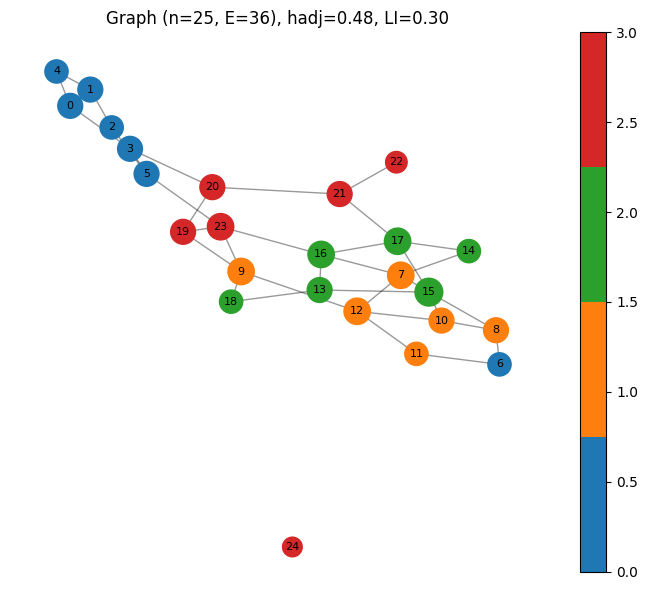

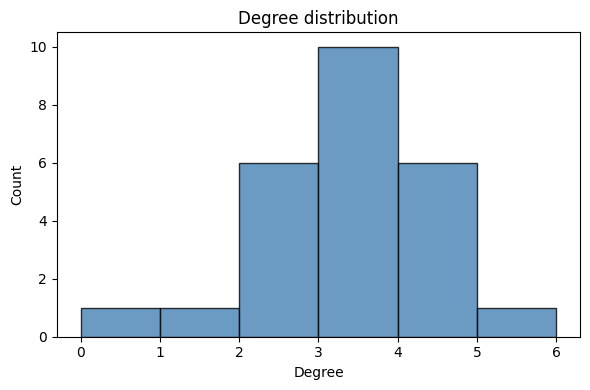

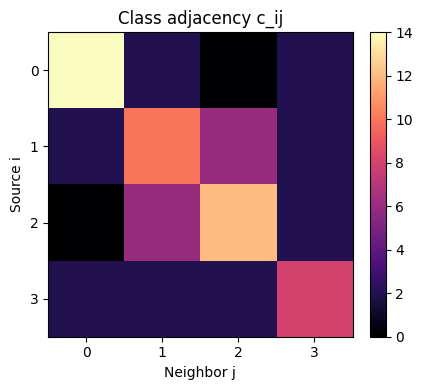

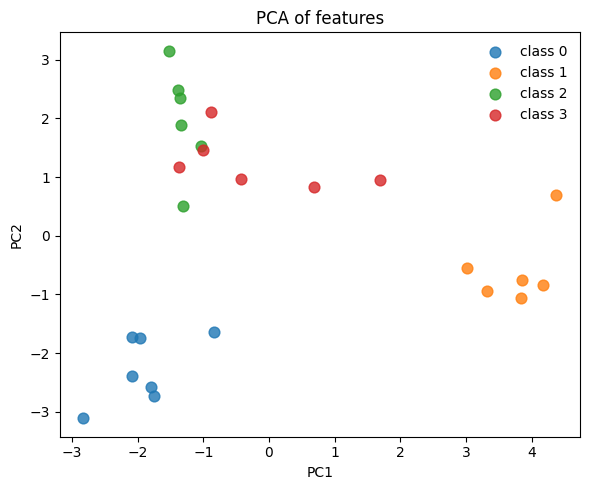

[B] done. Saved to synthetic_graph_B/


In [1]:
# %% [markdown]
# Synthetic graph generator (Regime A + Regime B) with strict reproducibility
# Following arXiv:2209.06177v5 dataset design principles.
#
# Outputs per regime (A=informative heterophily, B=moderate homophily):
#   - nodes.csv, features.csv, edges.csv, metadata.json
#   - graph.png, degree_hist.png, class_adj.png, pca.png
#
# Reproducible via fixed seeds and stored config in metadata.json

import os, json, math, random, csv
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA


# =====================================================
# Config
# =====================================================
@dataclass
class GenerationConfig:
    seed: int = 42
    num_nodes: int = 25
    num_features: int = 15
    num_classes: int = 4
    class_sizes: Tuple[int, ...] = (7, 6, 6, 6)
    regime: str = "A"  # "A" informative heterophily, "B" moderate homophily
    # SBM probabilities
    p0_A: float = 0.12; p1_A: float = 0.22; p2_A: float = 0.06
    p0_B: float = 0.28; p1_B: float = 0.12; p2_B: float = 0.06
    paired_cross: Tuple[Tuple[int, int], ...] = ((0, 3), (1, 2))
    feature_sigma: float = 0.6
    max_resamples: int = 50
    target_A_hadj_range: Tuple[float, float] = (-0.05, 0.15)
    target_A_LI_range: Tuple[float, float] = (0.15, 0.45)
    target_B_hadj_range: Tuple[float, float] = (0.30, 0.60)
    target_B_LI_range: Tuple[float, float] = (0.25, 0.55)
    split_sizes: Tuple[int, int, int] = (12, 6, 7)


# =====================================================
# Utils
# =====================================================
def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)


def stratified_split(labels: np.ndarray, sizes: Tuple[int, int, int], rng: random.Random) -> List[str]:
    n = len(labels)
    assert sum(sizes) == n
    unique = np.unique(labels)
    per_class = {c: np.where(labels == c)[0].tolist() for c in unique}
    for c in unique: rng.shuffle(per_class[c])

    train_target, val_target, test_target = sizes
    splits = [""] * n

    def assign_for_split(name: str, target: int):
        alloc = {c: int(round(target * (len(per_class[c]) / n))) for c in unique}
        diff = target - sum(alloc.values())
        i = 0; order = sorted(unique, key=lambda c: len(per_class[c]), reverse=True)
        while diff != 0:
            c = order[i % len(order)]
            if diff > 0: alloc[c]+=1; diff-=1
            elif diff < 0 and alloc[c]>0: alloc[c]-=1; diff+=1
            i+=1
        for c in unique:
            take = min(alloc[c], len(per_class[c]))
            chosen = per_class[c][:take]
            for idx in chosen: splits[idx] = name
            per_class[c] = per_class[c][take:]

    assign_for_split("train", train_target)
    assign_for_split("val", val_target)
    assign_for_split("test", test_target)
    for i in range(n):
        if splits[i]=="": splits[i]="test"
    return splits


def paired_class(i,j,pairs): return any((i==a and j==b) or (i==b and j==a) for a,b in pairs)


def sample_edges(labels, p0,p1,p2, paired_cross, rng):
    n=len(labels); edges=[]
    for u in range(n):
        for v in range(u+1,n):
            if labels[u]==labels[v]: p=p0
            elif paired_class(labels[u],labels[v],paired_cross): p=p1
            else: p=p2
            if rng.random()<p: edges.append((u,v))
    return edges


def generate_features(labels,d,sigma,rng):
    classes=np.unique(labels)
    means={c:rng.normal(0,1,size=d) for c in classes}
    X=np.zeros((len(labels),d))
    for i,c in enumerate(labels):
        X[i]=rng.normal(loc=means[c],scale=sigma,size=d)
    return X


def adjusted_homophily(labels,edges):
    E=len(edges)
    if E==0: return 0.0
    n=len(labels); deg=np.zeros(n,int)
    for u,v in edges: deg[u]+=1; deg[v]+=1
    classes=np.unique(labels)
    Dk={c:int(np.sum(deg[labels==c])) for c in classes}
    twoE=2*E; same=sum(1 for (u,v) in edges if labels[u]==labels[v])
    hedge=same/E; base=sum((Dk[c]/twoE)**2 for c in classes)
    return float((hedge-base)/(1.0-base+1e-12))


def label_informativeness_edge(labels,edges):
    E=len(edges)
    if E==0: return 0.0
    classes=np.unique(labels); C=len(classes)
    idx={c:i for i,c in enumerate(classes)}
    Cij=np.zeros((C,C))
    for u,v in edges:
        Cij[idx[labels[u]],idx[labels[v]]]+=1
        Cij[idx[labels[v]],idx[labels[u]]]+=1
    twoE=2*E; Pij=Cij/twoE; Pbar=Pij.sum(1)
    H=-float(np.sum([p*np.log(max(p,1e-12)) for p in Pbar]))
    I=0.0
    for i in range(C):
        for j in range(C):
            pij=Pij[i,j]
            if pij>0: I+=pij*np.log(pij/(Pbar[i]*Pbar[j]+1e-12))
    return float(max(0.0,min(1.0,I/H if H>1e-12 else 0.0)))


# =====================================================
# Main generator
# =====================================================
def generate_dataset(cfg: GenerationConfig, out_dir: str):
    os.makedirs(out_dir, exist_ok=True)
    set_seed(cfg.seed)
    rng_edges=random.Random(cfg.seed+1)
    rng_feat=np.random.default_rng(cfg.seed+2)

    best=None; accepted=False
    for _ in range(cfg.max_resamples):
        labels=np.concatenate([[c]*sz for c,sz in enumerate(cfg.class_sizes)])
        if cfg.regime=="A": p0,p1,p2=cfg.p0_A,cfg.p1_A,cfg.p2_A
        else: p0,p1,p2=cfg.p0_B,cfg.p1_B,cfg.p2_B
        edges=sample_edges(labels,p0,p1,p2,cfg.paired_cross,rng_edges)
        X=generate_features(labels,cfg.num_features,cfg.feature_sigma,rng_feat)
        hadj=adjusted_homophily(labels,edges)
        LI=label_informativeness_edge(labels,edges)
        if cfg.regime=="A": hr,lr=cfg.target_A_hadj_range,cfg.target_A_LI_range
        else: hr,lr=cfg.target_B_hadj_range,cfg.target_B_LI_range
        ok=(hr[0]<=hadj<=hr[1]) and (lr[0]<=LI<=lr[1])
        if ok: best=(labels,X,edges,hadj,LI); accepted=True; break
        if best is None: best=(labels,X,edges,hadj,LI)

    labels,X,edges,hadj,LI=best
    splits=stratified_split(labels,cfg.split_sizes,rng_edges)

    # Save CSVs
    with open(os.path.join(out_dir,"nodes.csv"),"w",newline="") as f:
        w=csv.writer(f); w.writerow(["id","label","split"])
        for i,(y,s) in enumerate(zip(labels,splits)): w.writerow([i,int(y),s])
    with open(os.path.join(out_dir,"features.csv"),"w",newline="") as f:
        w=csv.writer(f); header=["id"]+[f"f{k}" for k in range(X.shape[1])]; w.writerow(header)
        for i in range(X.shape[0]): w.writerow([i]+list(map(float,X[i])))
    with open(os.path.join(out_dir,"edges.csv"),"w",newline="") as f:
        w=csv.writer(f); w.writerow(["src","dst"]); [w.writerow([u,v]) for u,v in edges]

    metadata={
        "seed":cfg.seed,"regime":cfg.regime,
        "num_nodes":cfg.num_nodes,"num_features":cfg.num_features,"num_classes":cfg.num_classes,
        "class_sizes":cfg.class_sizes,"splits":dict(zip(["train","val","test"],cfg.split_sizes)),
        "probabilities":{"p0":p0,"p1":p1,"p2":p2,"paired_cross":cfg.paired_cross},
        "feature_sigma":cfg.feature_sigma,
        "measures":{"adjusted_homophily":hadj,"label_informativeness_edge":LI},
        "accepted":accepted
    }
    with open(os.path.join(out_dir,"metadata.json"),"w") as f: json.dump(metadata,f,indent=2)

    # -----------------------
    # Visualizations
    # -----------------------
    G=nx.Graph(); G.add_nodes_from(range(cfg.num_nodes)); G.add_edges_from(edges)
    deg=dict(G.degree()); classes=np.unique(labels)
    cmap=ListedColormap(['tab:blue','tab:orange','tab:green','tab:red'])

    # Graph plot
    pos=nx.spring_layout(G,seed=cfg.seed)
    plt.figure(figsize=(7,6))
    nx.draw_networkx_edges(G,pos,alpha=0.4)
    nodes=nx.draw_networkx_nodes(G,pos,node_color=[labels[i] for i in G.nodes()],
                                 cmap=cmap,node_size=[200+40*deg[i] for i in G.nodes()])
    nx.draw_networkx_labels(G,pos,labels={i:str(i) for i in G.nodes()},font_size=8)
    plt.title(f"Graph (n={cfg.num_nodes}, E={len(edges)}), hadj={hadj:.2f}, LI={LI:.2f}")
    plt.colorbar(nodes); plt.axis("off"); plt.tight_layout()
    plt.savefig(os.path.join(out_dir,"graph.png")); plt.show()

    # Degree histogram
    plt.figure(figsize=(6,4))
    plt.hist([deg[i] for i in G.nodes()], bins=range(0,max(deg.values())+2),
             alpha=0.8,color="steelblue",edgecolor="black")
    plt.xlabel("Degree"); plt.ylabel("Count"); plt.title("Degree distribution")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir,"degree_hist.png")); plt.show()

    # Class adjacency heatmap
    C=len(classes); idx={c:i for i,c in enumerate(sorted(classes))}
    Cij=np.zeros((C,C),dtype=int)
    for u,v in edges:
        Cij[idx[labels[u]],idx[labels[v]]]+=1
        Cij[idx[labels[v]],idx[labels[u]]]+=1
    plt.figure(figsize=(5,4))
    im=plt.imshow(Cij,cmap="magma")
    plt.title("Class adjacency c_ij"); plt.xlabel("Neighbor j"); plt.ylabel("Source i")
    plt.xticks(range(C),[str(int(c)) for c in sorted(classes)])
    plt.yticks(range(C),[str(int(c)) for c in sorted(classes)])
    plt.colorbar(im,fraction=0.046,pad=0.04)
    plt.tight_layout(); plt.savefig(os.path.join(out_dir,"class_adj.png")); plt.show()

    # PCA 2D scatter
    pca=PCA(n_components=2,random_state=cfg.seed); X2=pca.fit_transform(X)
    plt.figure(figsize=(6,5))
    for c in classes:
        pts=X2[labels==c]; plt.scatter(pts[:,0],pts[:,1],s=60,alpha=0.8,label=f"class {c}")
    plt.legend(frameon=False); plt.title("PCA of features"); plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir,"pca.png")); plt.show()

    print(f"[{cfg.regime}] done. Saved to {out_dir}/")


# =====================================================
# Run both regimes
# =====================================================
for regime in ["A","B"]:
    cfg=GenerationConfig(seed=42, regime=regime)
    out_dir=f"synthetic_graph_{regime}"
    generate_dataset(cfg,out_dir)


In [ ]:
# # %% [markdown]
# # QGNN-ready small graph dataset generator (single cell)
# #
# # - Nodes: 25
# # - Node features: 15-dim Gaussian per class
# # - Classes: 4 (sizes ~ [7, 6, 6, 6])
# # - Graph: SBM-like with paired cross-class preferences (0↔3, 1↔2) to control homophily vs informativeness
# # - Measures reported:
# #   - Adjusted homophily (assortativity) hadj (constant baseline under configuration-model null; comparable across datasets)
# #   - Label informativeness LI_edge (normalized mutual information of labels across uniformly sampled directed edges)
# #   - Optional LI_node (node-first, then neighbor) for degree-skew analysis
# # - Resampling attempts to better match target regimes (due to small n variability)
# # - Outputs written to: nodes.csv, features.csv, edges.csv, metadata.json
# #
# # Notes tying to the paper's standards (Platonov et al., NeurIPS 2023):
# # - Adjusted homophily (assortativity for categorical attributes) satisfies maximal agreement and asymptotic constant baseline,
# #   and is tolerant to empty classes → comparable across datasets with different class counts/imbalance.
# # - Label informativeness distinguishes heterophily patterns by quantifying how informative neighbor labels are (0..1),
# #   tends to 0 under configuration-model independence, and reaches 1 when neighbors uniquely determine labels.
# # - Using an SBM-like generator with paired cross-class preference lets us independently vary homophily (intra-class density p0)
# #   and informativeness (p1 vs p2), enabling informative heterophily or moderate homophily regimes.
# #
# # To switch regimes:
# #   - Regime "A": informative heterophily (low hadj, moderate LI)
# #   - Regime "B": moderate homophily (moderate hadj and LI)
# #
# # Run this cell; files will be created in the current working directory.

# # %% 
# import json
# import math
# import random
# from dataclasses import dataclass
# from typing import Dict, List, Tuple

# import numpy as np
# import networkx as nx
# import csv


# @dataclass
# class GenerationConfig:
#     seed: int = 42
#     num_nodes: int = 25
#     num_features: int = 15
#     num_classes: int = 4
#     class_sizes: Tuple[int, ...] = (7, 6, 6, 6)  # must sum to num_nodes
#     # Choose regime: "A" (informative heterophily) or "B" (moderate homophily)
#     regime: str = "A"
#     # SBM-like probabilities
#     p0_A: float = 0.12  # intra-class
#     p1_A: float = 0.22  # paired cross-class
#     p2_A: float = 0.06  # other cross-class
#     p0_B: float = 0.28
#     p1_B: float = 0.12
#     p2_B: float = 0.06
#     # Paired cross-class mapping (0↔3, 1↔2)
#     paired_cross: Tuple[Tuple[int, int], ...] = ((0, 3), (1, 2))
#     # Feature spread
#     feature_sigma: float = 0.6
#     # Resampling to hit target ranges (small n → noisy global stats)
#     max_resamples: int = 20
#     target_A_hadj_range: Tuple[float, float] = (-0.05, 0.15)
#     target_A_LI_range: Tuple[float, float] = (0.15, 0.45)
#     target_B_hadj_range: Tuple[float, float] = (0.30, 0.60)
#     target_B_LI_range: Tuple[float, float] = (0.25, 0.55)
#     # Splits
#     split_sizes: Tuple[int, int, int] = (12, 6, 7)  # train/val/test
#     # Outputs
#     nodes_csv: str = "nodes.csv"
#     features_csv: str = "features.csv"
#     edges_csv: str = "edges.csv"
#     metadata_json: str = "metadata.json"


# def set_seed(seed: int):
#     random.seed(seed)
#     np.random.seed(seed)


# def stratified_split(labels: np.ndarray, sizes: Tuple[int, int, int], rng: random.Random) -> List[str]:
#     n = len(labels)
#     assert sum(sizes) == n, "Split sizes must sum to number of nodes"
#     unique = np.unique(labels)
#     per_class = {c: np.where(labels == c)[0].tolist() for c in unique}
#     for c in unique:
#         rng.shuffle(per_class[c])

#     # Proportional targets
#     train_target, val_target, test_target = sizes
#     splits = [""] * n

#     def assign_for_split(split_name: str, target: int):
#         # initial proportional allocation with rounding
#         alloc = {c: int(round(target * (len(per_class[c]) / n))) for c in unique}
#         diff = target - sum(alloc.values())
#         # greedily fix rounding diff
#         if diff != 0:
#             order = sorted(unique, key=lambda c: len(per_class[c]), reverse=True)
#             i = 0
#             while diff != 0 and order:
#                 c = order[i % len(order)]
#                 # only adjust if feasible
#                 if diff > 0:
#                     alloc[c] += 1
#                     diff -= 1
#                 elif diff < 0 and alloc[c] > 0:
#                     alloc[c] -= 1
#                     diff += 1
#                 i += 1
#         # take from pools
#         for c in unique:
#             take = max(0, min(alloc[c], len(per_class[c])))
#             chosen = per_class[c][:take]
#             for idx in chosen:
#                 splits[idx] = split_name
#             per_class[c] = per_class[c][take:]

#     assign_for_split("train", train_target)
#     assign_for_split("val", val_target)
#     assign_for_split("test", test_target)

#     # any leftovers go to test
#     for i in range(n):
#         if splits[i] == "":
#             splits[i] = "test"
#     return splits


# def paired_class(i: int, j: int, paired_cross: Tuple[Tuple[int, int], ...]) -> bool:
#     return any((i == a and j == b) or (i == b and j == a) for (a, b) in paired_cross)


# def sample_edges(labels: np.ndarray,
#                  p0: float, p1: float, p2: float,
#                  paired_cross: Tuple[Tuple[int, int], ...],
#                  rng: random.Random) -> List[Tuple[int, int]]:
#     n = len(labels)
#     edges = []
#     for u in range(n):
#         for v in range(u + 1, n):
#             if labels[u] == labels[v]:
#                 p = p0
#             elif paired_class(labels[u], labels[v], paired_cross):
#                 p = p1
#             else:
#                 p = p2
#             if rng.random() < p:
#                 edges.append((u, v))
#     return edges


# def generate_features(labels: np.ndarray, d: int, sigma: float, rng: np.random.Generator) -> np.ndarray:
#     classes = np.unique(labels)
#     means = {c: rng.normal(0.0, 1.0, size=d) for c in classes}
#     X = np.zeros((len(labels), d), dtype=float)
#     for i, c in enumerate(labels):
#         X[i] = rng.normal(loc=means[c], scale=sigma, size=d)
#     return X


# def adjusted_homophily(labels: np.ndarray, edges: List[Tuple[int, int]]) -> float:
#     E = len(edges)
#     if E == 0:
#         return 0.0
#     n = len(labels)
#     deg = np.zeros(n, dtype=int)
#     for u, v in edges:
#         deg[u] += 1
#         deg[v] += 1
#     classes = np.unique(labels)
#     Dk = {c: int(np.sum(deg[labels == c])) for c in classes}
#     twoE = 2 * E
#     same = sum(1 for (u, v) in edges if labels[u] == labels[v])
#     hedge = same / E
#     base = sum((Dk[c] / twoE) ** 2 for c in classes)
#     denom = 1.0 - base
#     if denom <= 1e-12:
#         return 0.0
#     return float((hedge - base) / denom)


# def label_informativeness_edge(labels: np.ndarray, edges: List[Tuple[int, int]]) -> float:
#     E = len(edges)
#     if E == 0:
#         return 0.0
#     classes = sorted(np.unique(labels).tolist())
#     C = len(classes)
#     idx = {c: i for i, c in enumerate(classes)}
#     Cij = np.zeros((C, C), dtype=float)
#     for u, v in edges:
#         Cij[idx[labels[u]], idx[labels[v]]] += 1.0
#         Cij[idx[labels[v]], idx[labels[u]]] += 1.0
#     twoE = 2.0 * E
#     Pij = Cij / twoE
#     Pbar = Pij.sum(axis=1)
#     eps = 1e-12
#     H = -float(np.sum([p * math.log(max(p, eps)) for p in Pbar]))
#     if H <= 1e-15:
#         return 0.0
#     I = 0.0
#     for i in range(C):
#         for j in range(C):
#             pij = Pij[i, j]
#             if pij <= 0.0:
#                 continue
#             denom = max(Pbar[i] * Pbar[j], eps)
#             I += pij * math.log(pij / denom)
#     LI = I / H
#     return float(max(0.0, min(1.0, LI)))


# def label_informativeness_node(labels: np.ndarray, edges: List[Tuple[int, int]]) -> float:
#     E = len(edges)
#     if E == 0:
#         return 0.0
#     n = len(labels)
#     G = nx.Graph()
#     G.add_nodes_from(range(n))
#     G.add_edges_from(edges)

#     classes = sorted(np.unique(labels).tolist())
#     C = len(classes)
#     idx = {c: i for i, c in enumerate(classes)}
#     node_counts = np.array([np.sum(labels == c) for c in classes], dtype=float)
#     Pnode = node_counts / n

#     Pij = np.zeros((C, C), dtype=float)
#     for u in range(n):
#         nbrs = list(G.neighbors(u))
#         if not nbrs:
#             continue
#         pu = 1.0 / n
#         for v in nbrs:
#             Pij[idx[labels[u]], idx[labels[v]]] += pu / len(nbrs)

#     eps = 1e-12
#     H = -float(np.sum([p * math.log(max(p, eps)) for p in Pnode]))
#     if H <= 1e-15:
#         return 0.0
#     Pbar_src = Pnode
#     Pbar_dst = Pij.sum(axis=0)
#     I = 0.0
#     for i in range(C):
#         for j in range(C):
#             pij = Pij[i, j]
#             if pij <= 0.0:
#                 continue
#             denom = max(Pbar_src[i] * Pbar_dst[j], eps)
#             I += pij * math.log(pij / denom)
#     LI = I / H
#     return float(max(0.0, min(1.0, LI)))


# def pick_probabilities(cfg: GenerationConfig) -> Tuple[float, float, float]:
#     if cfg.regime.upper() == "A":
#         return cfg.p0_A, cfg.p1_A, cfg.p2_A
#     elif cfg.regime.upper() == "B":
#         return cfg.p0_B, cfg.p1_B, cfg.p2_B
#     else:
#         raise ValueError("Unknown regime; must be 'A' or 'B'.")


# def generate_labels(cfg: GenerationConfig) -> np.ndarray:
#     assert sum(cfg.class_sizes) == cfg.num_nodes, "class_sizes must sum to num_nodes"
#     labels = []
#     for c, sz in enumerate(cfg.class_sizes):
#         labels.extend([c] * sz)
#     return np.array(labels, dtype=int)


# def run_once(cfg: GenerationConfig, rs_edges: random.Random, rs_feat: np.random.Generator):
#     labels = generate_labels(cfg)
#     p0, p1, p2 = pick_probabilities(cfg)
#     edges = sample_edges(labels, p0, p1, p2, cfg.paired_cross, rs_edges)
#     X = generate_features(labels, cfg.num_features, cfg.feature_sigma, rs_feat)
#     hadj = adjusted_homophily(labels, edges)
#     LIe = label_informativeness_edge(labels, edges)
#     LIn = label_informativeness_node(labels, edges)
#     return labels, X, edges, hadj, LIe, LIn, (p0, p1, p2)


# def accept_sample(cfg: GenerationConfig, hadj: float, LIe: float) -> bool:
#     if cfg.regime.upper() == "A":
#         lo_h, hi_h = cfg.target_A_hadj_range
#         lo_l, hi_l = cfg.target_A_LI_range
#         return (lo_h <= hadj <= hi_h) and (lo_l <= LIe <= hi_l)
#     else:
#         lo_h, hi_h = cfg.target_B_hadj_range
#         lo_l, hi_l = cfg.target_B_LI_range
#         return (lo_h <= hadj <= hi_h) and (lo_l <= LIe <= hi_l)


# def save_outputs(cfg: GenerationConfig,
#                  labels: np.ndarray,
#                  X: np.ndarray,
#                  edges: List[Tuple[int, int]],
#                  hadj: float, LIe: float, LIn: float,
#                  probs: Tuple[float, float, float],
#                  splits: List[str]):
#     with open(cfg.nodes_csv, "w", newline="") as f:
#         w = csv.writer(f)
#         w.writerow(["id", "label", "split"])
#         for i, (y, s) in enumerate(zip(labels, splits)):
#             w.writerow([i, int(y), s])

#     with open(cfg.features_csv, "w", newline="") as f:
#         w = csv.writer(f)
#         header = ["id"] + [f"f{k}" for k in range(X.shape[1])]
#         w.writerow(header)
#         for i in range(X.shape[0]):
#             w.writerow([i] + [float(v) for v in X[i]])

#     with open(cfg.edges_csv, "w", newline="") as f:
#         w = csv.writer(f)
#         w.writerow(["src", "dst"])
#         for u, v in edges:
#             a, b = (u, v) if u < v else (v, u)
#             w.writerow([a, b])

#     E = len(edges)
#     degrees = [0] * cfg.num_nodes
#     for u, v in edges:
#         degrees[u] += 1
#         degrees[v] += 1
#     class_counts = {int(c): int(np.sum(labels == c)) for c in np.unique(labels)}
#     metadata = {
#         "task": "node_classification",
#         "graph_type": "simple_undirected",
#         "num_nodes": int(cfg.num_nodes),
#         "num_edges": int(E),
#         "num_features": int(cfg.num_features),
#         "num_classes": int(cfg.num_classes),
#         "class_counts": class_counts,
#         "degrees": degrees,
#         "generation": {
#             "model": "SBM_like_with_paired_cross_classes",
#             "regime": cfg.regime,
#             "probabilities": {"p0_intra": probs[0], "p1_paired_cross": probs[1], "p2_other_cross": probs[2]},
#             "paired_cross": cfg.paired_cross,
#             "feature_sigma": cfg.feature_sigma,
#             "seed": cfg.seed
#         },
#         "splits": {
#             "train": sum(1 for s in splits if s == "train"),
#             "val": sum(1 for s in splits if s == "val"),
#             "test": sum(1 for s in splits if s == "test")
#         },
#         "measures": {
#             "adjusted_homophily": hadj,
#             "label_informativeness_edge": LIe,
#             "label_informativeness_node": LIn
#         },
#         "notes": {
#             "homophily_property": "Adjusted homophily (assortativity) satisfies maximal agreement and asymptotic constant baseline; empty class tolerant; monotonicity holds for sufficiently large values.",
#             "li_property": "LI has maximal agreement and tends to 0 under configuration-model null; complements homophily by distinguishing heterophilous patterns.",
#             "comparability": "Reporting hadj and LI together enables fair cross-dataset comparison.",
#             "limitations": "Small n=25 yields higher variance in global stats; edges are sampled i.i.d. per SBM-like scheme; connectivity not enforced."
#         }
#     }
#     with open(cfg.metadata_json, "w") as f:
#         json.dump(metadata, f, indent=2)


# # ---- main execution ----
# cfg = GenerationConfig(
#     regime="A"  # change to "B" for moderate homophily preset
# )
# set_seed(cfg.seed)
# rs_edges = random.Random(cfg.seed + 1)
# rs_feat = np.random.default_rng(cfg.seed + 2)

# accepted = False
# best = None
# for attempt in range(cfg.max_resamples):
#     labels, X, edges, hadj, LIe, LIn, probs = run_once(cfg, rs_edges, rs_feat)
#     if accept_sample(cfg, hadj, LIe):
#         best = (labels, X, edges, hadj, LIe, LIn, probs)
#         accepted = True
#         break
#     if best is None:
#         best = (labels, X, edges, hadj, LIe, LIn, probs)
#     else:
#         if cfg.regime.upper() == "A":
#             hr = cfg.target_A_hadj_range
#             lr = cfg.target_A_LI_range
#         else:
#             hr = cfg.target_B_hadj_range
#             lr = cfg.target_B_LI_range

#         def dist(val, r):
#             if val < r[0]:
#                 return r[0] - val
#             if val > r[1]:
#                 return val - r[1]
#             return 0.0

#         cur_d = dist(hadj, hr) + dist(LIe, lr)
#         best_d = dist(best[3], hr) + dist(best[4], lr)
#         if cur_d < best_d:
#             best = (labels, X, edges, hadj, LIe, LIn, probs)

# labels, X, edges, hadj, LIe, LIn, probs = best

# splits = stratified_split(labels, cfg.split_sizes, rs_edges)
# save_outputs(cfg, labels, X, edges, hadj, LIe, LIn, probs, splits)

# print("Dataset generated.")
# print(f"Regime: {cfg.regime}")
# print(f"Nodes: {cfg.num_nodes}, Features: {cfg.num_features}, Classes: {cfg.num_classes}")
# print(f"Edges: {len(edges)}")
# print(f"Adjusted homophily (hadj): {hadj:.3f}")
# print(f"Label informativeness (edge) LI: {LIe:.3f}")
# print(f"Label informativeness (node) LI: {LIn:.3f}")
# print(f"Files written: {cfg.nodes_csv}, {cfg.features_csv}, {cfg.edges_csv}, {cfg.metadata_json}")


Dataset generated.
Regime: A
Nodes: 25, Features: 15, Classes: 4
Edges: 34
Adjusted homophily (hadj): 0.027
Label informativeness (edge) LI: 0.228
Label informativeness (node) LI: 0.263
Files written: nodes.csv, features.csv, edges.csv, metadata.json


Dataset generated.
Regime: A
Nodes: 25, Features: 15, Classes: 4
Edges: 34
Adjusted homophily (hadj): 0.027
Label informativeness (edge) LI: 0.228
Label informativeness (node) LI: 0.263
Files written: nodes.csv, features.csv, edges.csv, metadata.json


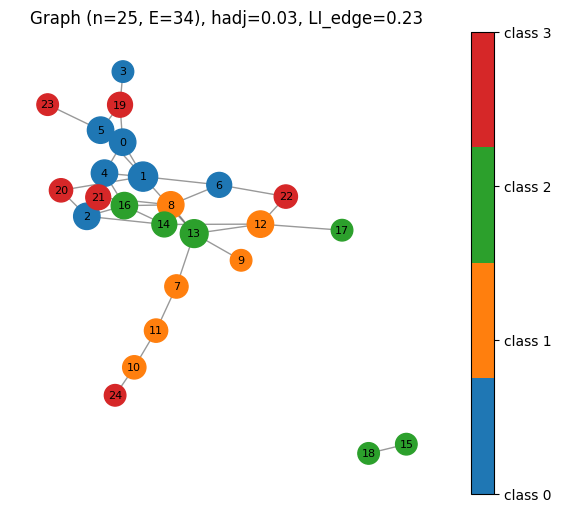

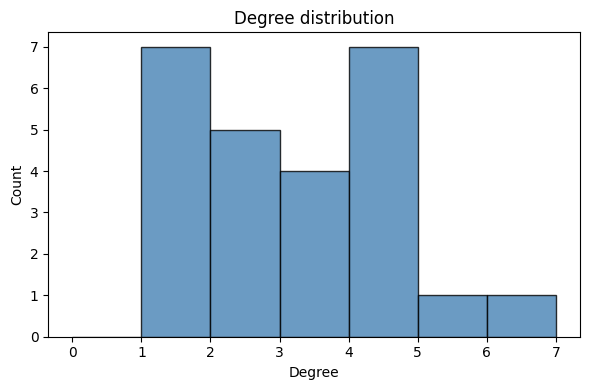

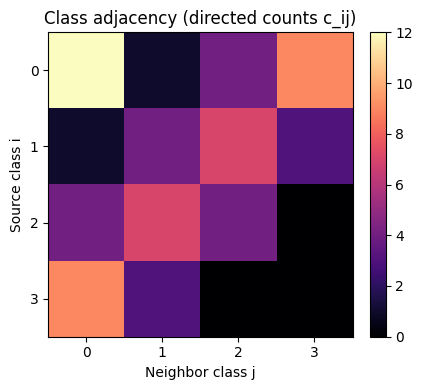

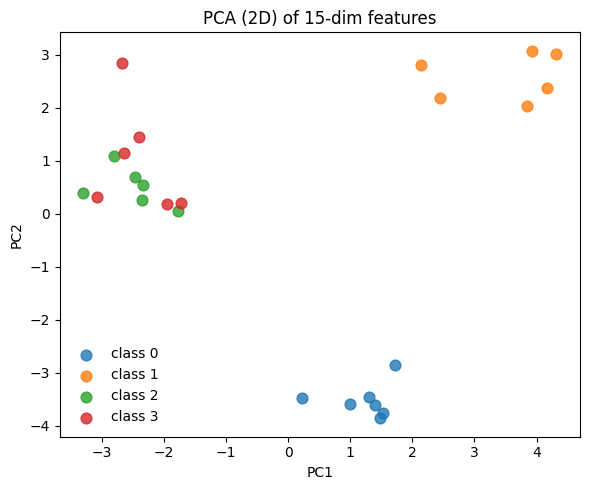

In [ ]:
# # %% [markdown]
# # QGNN-ready small graph dataset generator with visualization (single cell)
# #
# # - Nodes: 25
# # - Node features: 15-dim Gaussian per class
# # - Classes: 4 (sizes ~ [7, 6, 6, 6])
# # - Graph: SBM-like with paired cross-class preferences (0↔3, 1↔2) to control homophily vs informativeness
# # - Measures reported:
# #   - Adjusted homophily (assortativity) hadj (constant baseline under configuration-model null; comparable across datasets)
# #   - Label informativeness LI_edge (normalized mutual information of labels across uniformly sampled directed edges)
# #   - Optional LI_node (node-first, then neighbor) for degree-skew analysis
# # - Resampling attempts to better match target regimes (due to small n variability)
# # - Outputs written to: nodes.csv, features.csv, edges.csv, metadata.json
# # - Visualizations:
# #   1) Graph plot (nodes colored by class, labels shown)
# #   2) Degree distribution histogram
# #   3) Class adjacency heatmap (directed counts c_ij over ordered edge-ends)
# #   4) Scatter of 2D PCA of features, colored by class
# #
# # To switch regimes:
# #   - Regime "A": informative heterophily (low hadj, moderate LI)
# #   - Regime "B": moderate homophily (moderate hadj and LI)
# #
# # Run this cell; files will be created in the current working directory and plots displayed inline.

# # %%
# import json
# import math
# import random
# from dataclasses import dataclass
# from typing import List, Tuple

# import numpy as np
# import networkx as nx
# import csv
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap
# from sklearn.decomposition import PCA


# @dataclass
# class GenerationConfig:
#     seed: int = 42
#     num_nodes: int = 25
#     num_features: int = 15
#     num_classes: int = 4
#     class_sizes: Tuple[int, ...] = (7, 6, 6, 6)  # must sum to num_nodes
#     # Choose regime: "A" (informative heterophily) or "B" (moderate homophily)
#     regime: str = "A"
#     # SBM-like probabilities
#     p0_A: float = 0.12  # intra-class
#     p1_A: float = 0.22  # paired cross-class
#     p2_A: float = 0.06  # other cross-class
#     p0_B: float = 0.28
#     p1_B: float = 0.12
#     p2_B: float = 0.06
#     # Paired cross-class mapping (0↔3, 1↔2)
#     paired_cross: Tuple[Tuple[int, int], ...] = ((0, 3), (1, 2))
#     # Feature spread
#     feature_sigma: float = 0.6
#     # Resampling to hit target ranges (small n → noisy global stats)
#     max_resamples: int = 20
#     target_A_hadj_range: Tuple[float, float] = (-0.05, 0.15)
#     target_A_LI_range: Tuple[float, float] = (0.15, 0.45)
#     target_B_hadj_range: Tuple[float, float] = (0.30, 0.60)
#     target_B_LI_range: Tuple[float, float] = (0.25, 0.55)
#     # Splits
#     split_sizes: Tuple[int, int, int] = (12, 6, 7)  # train/val/test
#     # Outputs
#     nodes_csv: str = "nodes.csv"
#     features_csv: str = "features.csv"
#     edges_csv: str = "edges.csv"
#     metadata_json: str = "metadata.json"


# def set_seed(seed: int):
#     random.seed(seed)
#     np.random.seed(seed)


# def stratified_split(labels: np.ndarray, sizes: Tuple[int, int, int], rng: random.Random) -> List[str]:
#     n = len(labels)
#     assert sum(sizes) == n, "Split sizes must sum to number of nodes"
#     unique = np.unique(labels)
#     per_class = {c: np.where(labels == c)[0].tolist() for c in unique}
#     for c in unique:
#         rng.shuffle(per_class[c])

#     train_target, val_target, test_target = sizes
#     splits = [""] * n

#     def assign_for_split(split_name: str, target: int):
#         alloc = {c: int(round(target * (len(per_class[c]) / n))) for c in unique}
#         diff = target - sum(alloc.values())
#         if diff != 0:
#             order = sorted(unique, key=lambda c: len(per_class[c]), reverse=True)
#             i = 0
#             while diff != 0 and order:
#                 c = order[i % len(order)]
#                 if diff > 0:
#                     alloc[c] += 1
#                     diff -= 1
#                 elif diff < 0 and alloc[c] > 0:
#                     alloc[c] -= 1
#                     diff += 1
#                 i += 1
#         for c in unique:
#             take = max(0, min(alloc[c], len(per_class[c])))
#             chosen = per_class[c][:take]
#             for idx in chosen:
#                 splits[idx] = split_name
#             per_class[c] = per_class[c][take:]

#     assign_for_split("train", train_target)
#     assign_for_split("val", val_target)
#     assign_for_split("test", test_target)

#     for i in range(n):
#         if splits[i] == "":
#             splits[i] = "test"
#     return splits


# def paired_class(i: int, j: int, paired_cross: Tuple[Tuple[int, int], ...]) -> bool:
#     return any((i == a and j == b) or (i == b and j == a) for (a, b) in paired_cross)


# def sample_edges(labels: np.ndarray,
#                  p0: float, p1: float, p2: float,
#                  paired_cross: Tuple[Tuple[int, int], ...],
#                  rng: random.Random) -> List[Tuple[int, int]]:
#     n = len(labels)
#     edges = []
#     for u in range(n):
#         for v in range(u + 1, n):
#             if labels[u] == labels[v]:
#                 p = p0
#             elif paired_class(labels[u], labels[v], paired_cross):
#                 p = p1
#             else:
#                 p = p2
#             if rng.random() < p:
#                 edges.append((u, v))
#     return edges


# def generate_features(labels: np.ndarray, d: int, sigma: float, rng: np.random.Generator) -> np.ndarray:
#     classes = np.unique(labels)
#     means = {c: rng.normal(0.0, 1.0, size=d) for c in classes}
#     X = np.zeros((len(labels), d), dtype=float)
#     for i, c in enumerate(labels):
#         X[i] = rng.normal(loc=means[c], scale=sigma, size=d)
#     return X


# def adjusted_homophily(labels: np.ndarray, edges: List[Tuple[int, int]]) -> float:
#     E = len(edges)
#     if E == 0:
#         return 0.0
#     n = len(labels)
#     deg = np.zeros(n, dtype=int)
#     for u, v in edges:
#         deg[u] += 1
#         deg[v] += 1
#     classes = np.unique(labels)
#     Dk = {c: int(np.sum(deg[labels == c])) for c in classes}
#     twoE = 2 * E
#     same = sum(1 for (u, v) in edges if labels[u] == labels[v])
#     hedge = same / E
#     base = sum((Dk[c] / twoE) ** 2 for c in classes)
#     denom = 1.0 - base
#     if denom <= 1e-12:
#         return 0.0
#     return float((hedge - base) / denom)


# def label_informativeness_edge(labels: np.ndarray, edges: List[Tuple[int, int]]) -> float:
#     E = len(edges)
#     if E == 0:
#         return 0.0
#     classes = sorted(np.unique(labels).tolist())
#     C = len(classes)
#     idx = {c: i for i, c in enumerate(classes)}
#     Cij = np.zeros((C, C), dtype=float)
#     for u, v in edges:
#         Cij[idx[labels[u]], idx[labels[v]]] += 1.0
#         Cij[idx[labels[v]], idx[labels[u]]] += 1.0
#     twoE = 2.0 * E
#     Pij = Cij / twoE
#     Pbar = Pij.sum(axis=1)
#     eps = 1e-12
#     H = -float(np.sum([p * math.log(max(p, eps)) for p in Pbar]))
#     if H <= 1e-15:
#         return 0.0
#     I = 0.0
#     for i in range(C):
#         for j in range(C):
#             pij = Pij[i, j]
#             if pij <= 0.0:
#                 continue
#             denom = max(Pbar[i] * Pbar[j], eps)
#             I += pij * math.log(pij / denom)
#     LI = I / H
#     return float(max(0.0, min(1.0, LI)))


# def label_informativeness_node(labels: np.ndarray, edges: List[Tuple[int, int]]) -> float:
#     E = len(edges)
#     if E == 0:
#         return 0.0
#     n = len(labels)
#     G = nx.Graph()
#     G.add_nodes_from(range(n))
#     G.add_edges_from(edges)

#     classes = sorted(np.unique(labels).tolist())
#     C = len(classes)
#     idx = {c: i for i, c in enumerate(classes)}
#     node_counts = np.array([np.sum(labels == c) for c in classes], dtype=float)
#     Pnode = node_counts / n

#     Pij = np.zeros((C, C), dtype=float)
#     for u in range(n):
#         nbrs = list(G.neighbors(u))
#         if not nbrs:
#             continue
#         pu = 1.0 / n
#         for v in nbrs:
#             Pij[idx[labels[u]], idx[labels[v]]] += pu / len(nbrs)

#     eps = 1e-12
#     H = -float(np.sum([p * math.log(max(p, eps)) for p in Pnode]))
#     if H <= 1e-15:
#         return 0.0
#     Pbar_src = Pnode
#     Pbar_dst = Pij.sum(axis=0)
#     I = 0.0
#     for i in range(C):
#         for j in range(C):
#             pij = Pij[i, j]
#             if pij <= 0.0:
#                 continue
#             denom = max(Pbar_src[i] * Pbar_dst[j], eps)
#             I += pij * math.log(pij / denom)
#     LI = I / H
#     return float(max(0.0, min(1.0, LI)))


# def pick_probabilities(cfg: GenerationConfig) -> Tuple[float, float, float]:
#     if cfg.regime.upper() == "A":
#         return cfg.p0_A, cfg.p1_A, cfg.p2_A
#     elif cfg.regime.upper() == "B":
#         return cfg.p0_B, cfg.p1_B, cfg.p2_B
#     else:
#         raise ValueError("Unknown regime; must be 'A' or 'B'.")


# def generate_labels(cfg: GenerationConfig) -> np.ndarray:
#     assert sum(cfg.class_sizes) == cfg.num_nodes, "class_sizes must sum to num_nodes"
#     labels = []
#     for c, sz in enumerate(cfg.class_sizes):
#         labels.extend([c] * sz)
#     return np.array(labels, dtype=int)


# def run_once(cfg: GenerationConfig, rs_edges: random.Random, rs_feat: np.random.Generator):
#     labels = generate_labels(cfg)
#     p0, p1, p2 = pick_probabilities(cfg)
#     edges = sample_edges(labels, p0, p1, p2, cfg.paired_cross, rs_edges)
#     X = generate_features(labels, cfg.num_features, cfg.feature_sigma, rs_feat)
#     hadj = adjusted_homophily(labels, edges)
#     LIe = label_informativeness_edge(labels, edges)
#     LIn = label_informativeness_node(labels, edges)
#     return labels, X, edges, hadj, LIe, LIn, (p0, p1, p2)


# def accept_sample(cfg: GenerationConfig, hadj: float, LIe: float) -> bool:
#     if cfg.regime.upper() == "A":
#         lo_h, hi_h = cfg.target_A_hadj_range
#         lo_l, hi_l = cfg.target_A_LI_range
#         return (lo_h <= hadj <= hi_h) and (lo_l <= LIe <= hi_l)
#     else:
#         lo_h, hi_h = cfg.target_B_hadj_range
#         lo_l, hi_l = cfg.target_B_LI_range
#         return (lo_h <= hadj <= hi_h) and (lo_l <= LIe <= hi_l)


# def save_outputs(cfg: GenerationConfig,
#                  labels: np.ndarray,
#                  X: np.ndarray,
#                  edges: List[Tuple[int, int]],
#                  hadj: float, LIe: float, LIn: float,
#                  probs: Tuple[float, float, float],
#                  splits: List[str]):
#     with open(cfg.nodes_csv, "w", newline="") as f:
#         w = csv.writer(f)
#         w.writerow(["id", "label", "split"])
#         for i, (y, s) in enumerate(zip(labels, splits)):
#             w.writerow([i, int(y), s])

#     with open(cfg.features_csv, "w", newline="") as f:
#         w = csv.writer(f)
#         header = ["id"] + [f"f{k}" for k in range(X.shape[1])]
#         w.writerow(header)
#         for i in range(X.shape[0]):
#             w.writerow([i] + [float(v) for v in X[i]])

#     with open(cfg.edges_csv, "w", newline="") as f:
#         w = csv.writer(f)
#         w.writerow(["src", "dst"])
#         for u, v in edges:
#             a, b = (u, v) if u < v else (v, u)
#             w.writerow([a, b])

#     E = len(edges)
#     degrees = [0] * cfg.num_nodes
#     for u, v in edges:
#         degrees[u] += 1
#         degrees[v] += 1
#     class_counts = {int(c): int(np.sum(labels == c)) for c in np.unique(labels)}
#     metadata = {
#         "task": "node_classification",
#         "graph_type": "simple_undirected",
#         "num_nodes": int(cfg.num_nodes),
#         "num_edges": int(E),
#         "num_features": int(cfg.num_features),
#         "num_classes": int(cfg.num_classes),
#         "class_counts": class_counts,
#         "degrees": degrees,
#         "generation": {
#             "model": "SBM_like_with_paired_cross_classes",
#             "regime": cfg.regime,
#             "probabilities": {"p0_intra": probs[0], "p1_paired_cross": probs[1], "p2_other_cross": probs[2]},
#             "paired_cross": cfg.paired_cross,
#             "feature_sigma": cfg.feature_sigma,
#             "seed": cfg.seed
#         },
#         "splits": {
#             "train": sum(1 for s in splits if s == "train"),
#             "val": sum(1 for s in splits if s == "val"),
#             "test": sum(1 for s in splits if s == "test")
#         },
#         "measures": {
#             "adjusted_homophily": hadj,
#             "label_informativeness_edge": LIe,
#             "label_informativeness_node": LIn
#         },
#         "notes": {
#             "homophily_property": "Adjusted homophily (assortativity) satisfies maximal agreement and asymptotic constant baseline; empty class tolerant; monotonicity holds for sufficiently large values.",
#             "li_property": "LI has maximal agreement and tends to 0 under configuration-model null; complements homophily by distinguishing heterophilous patterns.",
#             "comparability": "Reporting hadj and LI together enables fair cross-dataset comparison.",
#             "limitations": "Small n=25 yields higher variance in global stats; edges are sampled i.i.d. per SBM-like scheme; connectivity not enforced."
#         }
#     }
#     with open(cfg.metadata_json, "w") as f:
#         json.dump(metadata, f, indent=2)


# # ---------------------
# # Main generation
# # ---------------------
# cfg = GenerationConfig(
#     regime="A"  # change to "B" for moderate homophily preset
# )
# set_seed(cfg.seed)
# rs_edges = random.Random(cfg.seed + 1)
# rs_feat = np.random.default_rng(cfg.seed + 2)

# accepted = False
# best = None
# for attempt in range(cfg.max_resamples):
#     labels, X, edges, hadj, LIe, LIn, probs = run_once(cfg, rs_edges, rs_feat)
#     if accept_sample(cfg, hadj, LIe):
#         best = (labels, X, edges, hadj, LIe, LIn, probs)
#         accepted = True
#         break
#     if best is None:
#         best = (labels, X, edges, hadj, LIe, LIn, probs)
#     else:
#         if cfg.regime.upper() == "A":
#             hr = cfg.target_A_hadj_range
#             lr = cfg.target_A_LI_range
#         else:
#             hr = cfg.target_B_hadj_range
#             lr = cfg.target_B_LI_range

#         def dist(val, r):
#             if val < r[0]:
#                 return r[0] - val
#             if val > r[1]:
#                 return val - r[1]
#             return 0.0

#         cur_d = dist(hadj, hr) + dist(LIe, lr)
#         best_d = dist(best[3], hr) + dist(best[4], lr)
#         if cur_d < best_d:
#             best = (labels, X, edges, hadj, LIe, LIn, probs)

# labels, X, edges, hadj, LIe, LIn, probs = best

# splits = stratified_split(labels, cfg.split_sizes, rs_edges)
# save_outputs(cfg, labels, X, edges, hadj, LIe, LIn, probs, splits)

# print("Dataset generated.")
# print(f"Regime: {cfg.regime}")
# print(f"Nodes: {cfg.num_nodes}, Features: {cfg.num_features}, Classes: {cfg.num_classes}")
# print(f"Edges: {len(edges)}")
# print(f"Adjusted homophily (hadj): {hadj:.3f}")
# print(f"Label informativeness (edge) LI: {LIe:.3f}")
# print(f"Label informativeness (node) LI: {LIn:.3f}")
# print(f"Files written: {cfg.nodes_csv}, {cfg.features_csv}, {cfg.edges_csv}, {cfg.metadata_json}")

# # ---------------------
# # Visualizations
# # ---------------------

# # Build graph
# G = nx.Graph()
# G.add_nodes_from(range(cfg.num_nodes))
# G.add_edges_from(edges)
# deg = dict(G.degree())
# classes = np.unique(labels)

# # 1) Graph plot
# plt.figure(figsize=(7, 6))
# pos = nx.spring_layout(G, seed=cfg.seed)  # reproducible layout
# cmap = ListedColormap(['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
# node_colors = [labels[i] for i in G.nodes()]
# sizes = [200 + 40 * deg[i] for i in G.nodes()]
# nx.draw_networkx_edges(G, pos, alpha=0.4)
# nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=cmap, node_size=sizes)
# nx.draw_networkx_labels(G, pos, labels={i: str(i) for i in G.nodes()}, font_size=8)
# plt.title(f"Graph (n={cfg.num_nodes}, E={len(edges)}), hadj={hadj:.2f}, LI_edge={LIe:.2f}")
# cbar = plt.colorbar(nodes)
# cbar.set_ticks(range(len(classes)))
# cbar.set_ticklabels([f"class {int(c)}" for c in classes])
# plt.axis('off')
# plt.show()

# # 2) Degree distribution
# plt.figure(figsize=(6, 4))
# plt.hist([deg[i] for i in G.nodes()], bins=range(0, max(deg.values()) + 2), alpha=0.8, color='steelblue', edgecolor='black')
# plt.xlabel("Degree")
# plt.ylabel("Count")
# plt.title("Degree distribution")
# plt.tight_layout()
# plt.show()

# # 3) Class adjacency heatmap (directed counts c_ij from ordered edge-ends)
# C = len(classes)
# idx = {c: i for i, c in enumerate(sorted(classes))}
# Cij = np.zeros((C, C), dtype=int)
# for u, v in edges:
#     Cij[idx[labels[u]], idx[labels[v]]] += 1
#     Cij[idx[labels[v]], idx[labels[u]]] += 1

# plt.figure(figsize=(5, 4))
# im = plt.imshow(Cij, cmap="magma")
# plt.title("Class adjacency (directed counts c_ij)")
# plt.xlabel("Neighbor class j")
# plt.ylabel("Source class i")
# plt.xticks(range(C), [str(int(c)) for c in sorted(classes)])
# plt.yticks(range(C), [str(int(c)) for c in sorted(classes)])
# plt.colorbar(im, fraction=0.046, pad=0.04)
# plt.tight_layout()
# plt.show()

# # 4) 2D PCA of features
# pca = PCA(n_components=2, random_state=cfg.seed)
# X2 = pca.fit_transform(X)
# plt.figure(figsize=(6, 5))
# for c in classes:
#     pts = X2[labels == c]
#     plt.scatter(pts[:, 0], pts[:, 1], s=60, alpha=0.8, label=f"class {int(c)}")
# plt.legend(frameon=False)
# plt.title("PCA (2D) of 15-dim features")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.tight_layout()
# plt.show()
